## LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import fcluster

from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans

import umap
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# umap cluster lines 
from scipy.interpolate import splprep, splev
import alphashape
from shapely.geometry import MultiPolygon

In [2]:
# hide warning 
import warnings
warnings.filterwarnings('ignore')

## FUNCTIONS

### ASSIGN CATEGORY

In [3]:
def assign_category(text):
    '''
    function to reassign labels in Stakeholder Group column 
    '''
    text = str(text).lower()

    if any(x in text for x in [
        'patient'
        , 'nmosd'
        , 'ms patient'
        , 'patient co-creation'
    ]):
        return 'Patient'

    elif any(x in text for x in [
        'caregiver'
        , 'parent'
        , 'child'
        , 'family'
        , 'support group'
    ]):
        return 'Caregiver'

    elif any(x in text for x in [
        'clinician'
        , 'allied health'
        , 'researcher'
        , 'training institution'
        , 'research support'
        , 'hospital and health systems'
        , 'industry'
        , 'genentech'
        , 'ceo'
        , 'policy maker'
    ]):
        return 'Clinician'

    else:
        return 'Other'

### PLOT HULLS AROUND EACH CLUSTER

In [4]:
# def plot_cluster_hulls(ax, embedding, clusters, alpha=2.0, padding=0.0, smooth=True, clusters_to_plot=None):
#     '''
#     function to draw outline boundaries (hulls) around clusters of points in the UMAP using an alpha shape to follow the irregular clusters of shapes 
#     input:  ax = Matplolib axes 
#             embedding = NumPy array of the shape containig the coordinates 
#             clusters = cluster label for each poiny 
#             alpha = how tightly the alpha shape fits each point 
#             padding = space from points to hull 
#             smooth = boundary line 
#             clusters_to_plot = select which clusters to plot 
#     output: UMAP with defined clusters
#     '''
#     # get all distinct cluster labels 
#     unique_clusters = np.unique(clusters)

#     # check if there is a cluster to plot 
#     if clusters_to_plot is not None:
#         # allow passing a single value or a list
#         if not isinstance(clusters_to_plot, (list, tuple, np.ndarray)):
#             clusters_to_plot = [clusters_to_plot]
#         # keep only the clusters_to_plot
#         unique_clusters = [c for c in unique_clusters if c in clusters_to_plot]

#     # use matplotlib's tab10 for colors, and keep them the same when plotting a subset 
#     cmap = plt.cm.tab10
#     all_clusters = np.unique(clusters)  

#     # loop through the clusters to be drawn 
#     for c in unique_clusters:
#         # index current cluster 
#         i = list(all_clusters).index(c)
#         # select the UMAP coordinates of the index cluster
#         pts = embedding[clusters == c]
#         # skip if less than 4 points (alpha shape needs 4 points to cluster)
#         if len(pts) < 4:
#             continue
#         color = cmap(i / max(len(all_clusters) - 1, 1))

#         # create alpha shape to wrap around concave regions 
#         shape = alphashape.alphashape(pts, alpha)
#         if shape.is_empty:
#             continue

#         polygons = shape.geoms if isinstance(shape, MultiPolygon) else [shape]

#         # loop over every polygon and extract coordinates 
#         for poly in polygons:
#             x, y = poly.exterior.xy
#             x, y = np.array(x), np.array(y)

#             if padding != 0:
#                 centroid = np.array([x.mean(), y.mean()])
#                 x = x + (x - centroid[0]) * padding
#                 y = y + (y - centroid[1]) * padding

#             if smooth and len(x) > 3:
#                 pts_closed = np.vstack([x, y]).T
#                 tck, _ = splprep([pts_closed[:, 0], pts_closed[:, 1]], s=0, per=True)
#                 u_fine = np.linspace(0, 1, 200)
#                 x, y = splev(u_fine, tck)

#             # draw boundary on plot
#             ax.plot(x, y, color=color, lw=1.5)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from shapely.geometry import MultiPolygon
from scipy.interpolate import splprep, splev
import alphashape
def plot_cluster_hulls(ax, embedding, clusters, style="fill", alpha=2.0, padding=0.0,
                       smooth=True, clusters_to_plot=None, fill_alpha=0.25,
                       rounded=False, draw_edge=True):
    '''
    Draw a region around each cluster of points in a UMAP embedding.
    input:  ax = Matplotlib axes
            embedding = (n, 2) NumPy array of coordinates
            clusters = cluster label for each point
            style = "outline" (alpha-shape line), "fill" (shaded alpha shape), or "box" (rectangle)
            alpha = how tightly the alpha shape fits the points (0 gives a convex hull)
            padding = extra space around the points, in embedding units
            smooth = smooth the alpha-shape boundary with a spline
            clusters_to_plot = a single label or a list of labels to draw
            fill_alpha = transparency of the shading for "fill" and "box"
            rounded = use rounded corners for "box"
            draw_edge = draw an outline on top of the shading
    output: draws on ax
    '''
    all_clusters = np.unique(clusters)

    if clusters_to_plot is None:
        to_plot = all_clusters
    else:
        # allow passing a single value or a list
        if not isinstance(clusters_to_plot, (list, tuple, np.ndarray)):
            clusters_to_plot = [clusters_to_plot]
        to_plot = [c for c in all_clusters if c in clusters_to_plot]

    # tab10 colors, indexed by position in the full label list so a subset keeps the same colors
    cmap = plt.cm.tab10

    for c in to_plot:
        i = int(np.where(all_clusters == c)[0][0])
        color = cmap(i % 10)
        pts = embedding[clusters == c]
        if len(pts) == 0:
            continue

        # rectangles 
        if style == "box":
            xmin, ymin = pts.min(axis=0) - padding
            xmax, ymax = pts.max(axis=0) + padding
            w, h = xmax - xmin, ymax - ymin
            edge = color if draw_edge else "none"
            if rounded:
                patch = FancyBboxPatch((xmin, ymin), w, h,
                                       boxstyle=f"round,pad=0,rounding_size={0.15 * min(w, h)}",
                                       facecolor=color, alpha=fill_alpha, edgecolor="none", zorder=0)
                border = FancyBboxPatch((xmin, ymin), w, h,
                                        boxstyle=f"round,pad=0,rounding_size={0.15 * min(w, h)}",
                                        facecolor="none", edgecolor=edge, lw=1.5, zorder=1)
            else:
                patch = Rectangle((xmin, ymin), w, h, facecolor=color, alpha=fill_alpha,
                                  edgecolor="none", zorder=0)
                border = Rectangle((xmin, ymin), w, h, facecolor="none",
                                   edgecolor=edge, lw=1.5, zorder=1)
            ax.add_patch(patch)
            ax.add_patch(border)
            continue

        # alpha shape (outline or fill) 
        if len(pts) < 4:
            continue
        shape = alphashape.alphashape(pts, alpha)
        if shape.is_empty:
            continue
        if padding:
            shape = shape.buffer(padding)  # grows the shape evenly outward

        polygons = shape.geoms if isinstance(shape, MultiPolygon) else [shape]

        for poly in polygons:
            if poly.geom_type != "Polygon":  # alphashape can return lines/points for sparse clusters
                continue
            x, y = (np.asarray(a) for a in poly.exterior.xy)

            if smooth and len(x) > 3:
                tck, _ = splprep([x, y], s=0, per=True)
                x, y = splev(np.linspace(0, 1, 200), tck)

            if style == "fill":
                ax.fill(x, y, color=color, alpha=fill_alpha, lw=0, zorder=0)
                if draw_edge:
                    ax.plot(x, y, color=color, lw=1.5, zorder=1)
            else:  # "outline"
                ax.plot(x, y, color=color, lw=1.5)

## DATAFRAME

In [ ]:
Welphi_HCA_Data = '/path/to/file'

In [7]:
# load data 
df = pd.read_csv(Welphi_HCA_Data)

In [8]:
# clean up & re-assign stakeholder groups 
df['Stakeholder Group'] = df['Stakeholder Group'].apply(assign_category)

## SELECT SINGLE COLUMN FOR ANALYSIS 

In [9]:
# select column
'''
Options:
    - Stakeholder Group 
        - Patient
        - Caregiver
        - Clinician 
    - NMOND (N) or MOGAD (M)
        - N
        - M
    - Lived Experience (L) or Professional/Researcher (R)
        - L
        - R
'''
# combine all groups
single_column_analysis = None

# single_column_analysis = 'L'
# df = df.loc[df['Lived Experience (L) or Professional/Researcher (R)'] == single_column_analysis]

### SEPARATE QUESTION COLUMNS OUT & FLAG THOSE WHO RANKED >60% AS 9; IPSATIZE

In [10]:
# separate question columns from metadata 
question_cols = [col for col in df.columns if col.startswith('T')]
df_rankings = df[question_cols]

# index = participant column
df_rankings.index = df['Participants']

# fill NaN values with the median ranking per question (using median because this is ordinal data)
df_rankings = df_rankings.fillna(df_rankings.median())

In [11]:
# flag people who rate >60% of items as 9 for a diagnostic
pct9 = (df_rankings == 9).sum(axis=1) / df_rankings.shape[1]
extreme_yes = pct9 > 0.60

#  ipsatize (row center): subtract each participant's mean across all topics
# so the value is now how the topic ranks relative to the person's average 
row_means = df_rankings.mean(axis=1)
df_rankings = df_rankings.sub(row_means, axis=0)

## HCA

In [12]:
# use a copy of the dataframe for clustering 
cluster_df = df.copy()

### DENDROGRAM BY SINGLE COLUMN

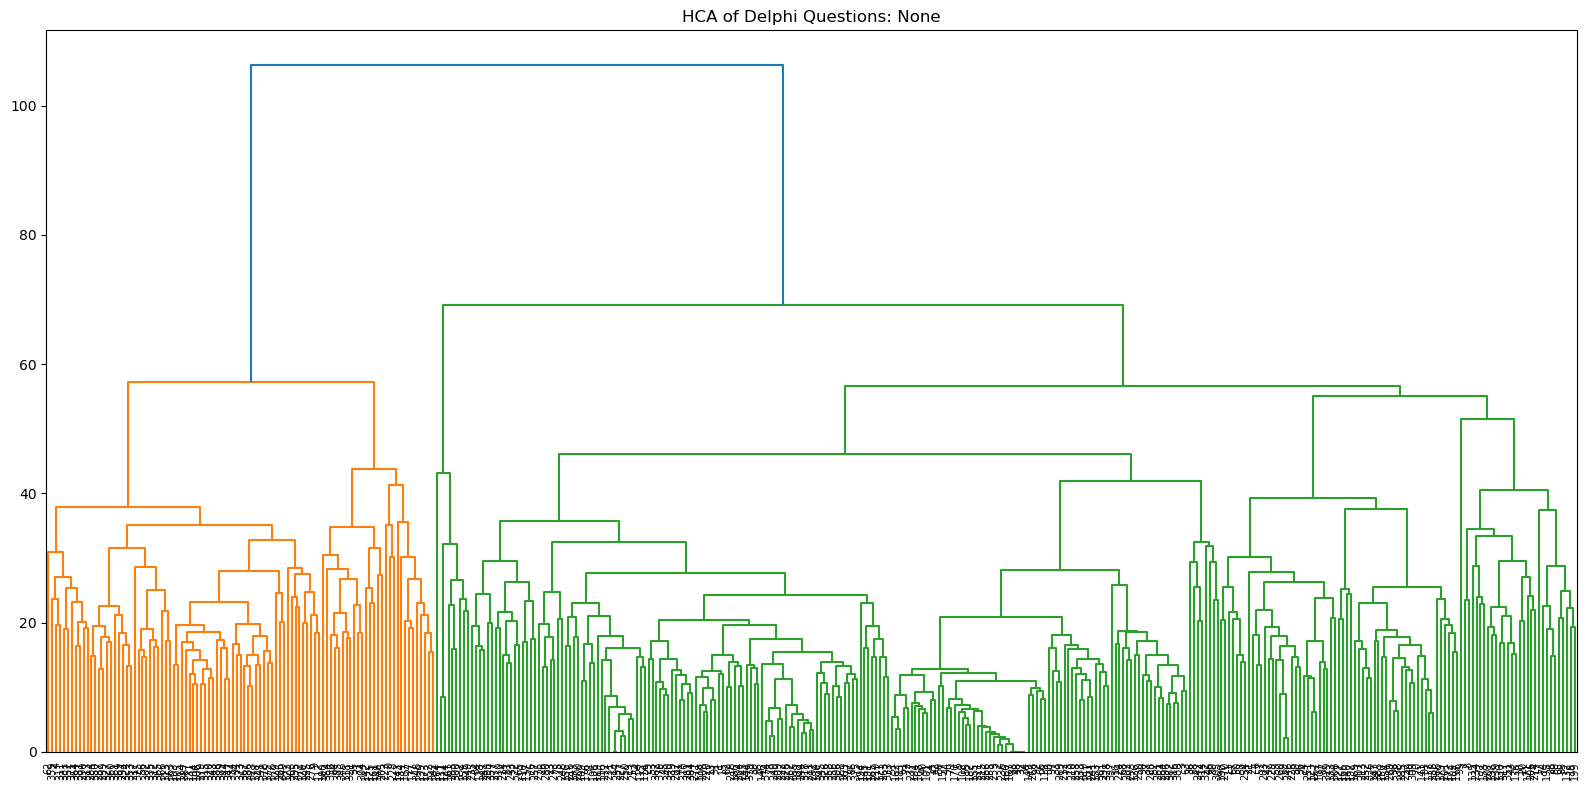

In [13]:
# linkage (Ward's method with euclidian distance)
Z = sch.linkage(df_rankings.values, method='ward', metric='euclidean')

# dendrogram 
plt.figure(figsize=(16, 8))
sch.dendrogram(Z, labels=None, leaf_rotation=90, leaf_font_size=7)
plt.title(f'HCA of Delphi Questions: {single_column_analysis}')
plt.tight_layout()
plt.show()

In [14]:
# number of clusters for loop
t_values = [2, 3, 4]

In [15]:
# compute cluster assignments for each t
for t in t_values:
    cluster_df[f'cluster_t{t}'] = fcluster(Z, t=t, criterion='maxclust')

#### ELBOW PLOT

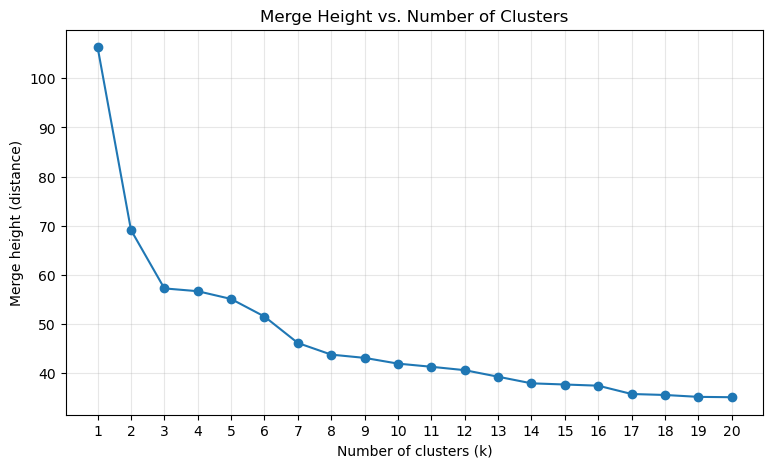

k=1 - 2: dropped -37.22
k=2 - 3: dropped -11.89
k=3 - 4: dropped -0.57
k=4 - 5: dropped -1.58
k=5 - 6: dropped -3.58
k=6 - 7: dropped -5.38
k=7 - 8: dropped -2.37
k=8 - 9: dropped -0.66
k=9 - 10: dropped -1.17
k=10 - 11: dropped -0.64
k=11 - 12: dropped -0.69
k=12 - 13: dropped -1.33
k=13 - 14: dropped -1.35
k=14 - 15: dropped -0.24
k=15 - 16: dropped -0.24
k=16 - 17: dropped -1.69
k=17 - 18: dropped -0.20
k=18 - 19: dropped -0.38
k=19 - 20: dropped -0.07


In [16]:
# distance matrix from df_rankings.values with metric='euclidean'
# pdist = condensed form; squareform = expanded to full square matrix
dist_matrix = squareform(pdist(df_rankings.values, metric='euclidean'))

# use cluster_df as metadata 
meta_df = cluster_df

# Z[:, 2] gets the merge height at each step, in ascending order
merge_heights = Z[:, 2]

# number of clusters remaining at each merge step, counting down from n samples to 1
n_samples = Z.shape[0] + 1

# reverse to plot in order of increasing cluster count (1 --> n)
heights_desc = merge_heights[::-1]
k_values = np.arange(1, n_samples)

plt.figure(figsize=(9, 5))
plt.plot(k_values[:20], heights_desc[:20], 'o-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Merge height (distance)')
plt.title('Merge Height vs. Number of Clusters')
plt.xticks(k_values[:20])
plt.grid(alpha=0.3)
plt.show()

# print height gaps between consecutive k (biggest gap = elbow)
height_gaps = np.diff(heights_desc[:20])
for k, gap in zip(k_values[:19], height_gaps):
    print(f"k={k} - {k+1}: dropped {gap:.2f}")  

#### SILHOUETTE SCORE

   k  silhouette_score
0  2          0.143846
1  3          0.146300
2  4          0.107069


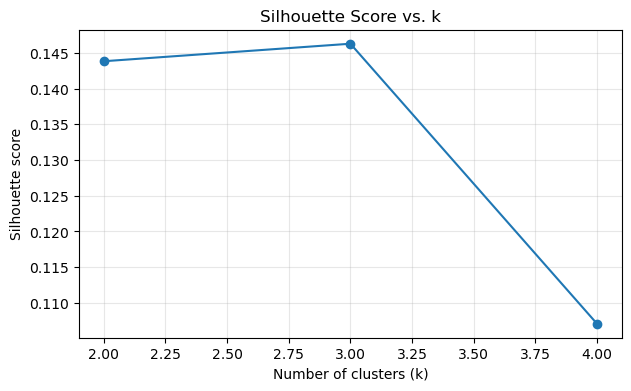

In [17]:
# use the same distance matrix from HCA
results = []

for t in t_values:
    labels = cluster_df[f'cluster_t{t}'].values
    score = silhouette_score(dist_matrix, labels, metric='precomputed')
    results.append({'k': t, 'silhouette_score': score})

# score ranges from -1 to 1: higher is better separated
# looking to see if k=2 scores highest and scores decline or plateau after (to confirm the dendrogram's story)
silhouette_df = pd.DataFrame(results)
print(silhouette_df)

plt.figure(figsize=(7, 4))
plt.plot(silhouette_df['k'], silhouette_df['silhouette_score'], 'o-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Score vs. k')
plt.grid(alpha=0.3)
plt.show()

#### CHI SQUARE

In [18]:
# loop over k values from t_values
for t in t_values:
    # cluster by stakeholder group column 
    contingency_table = pd.crosstab(cluster_df['Stakeholder Group'], cluster_df[f'cluster_t{t}'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f'\n--- k={t} ---')
    print(contingency_table)
    print(f'chi2={chi2:.3f}, dof={dof}, p={p_value:.4f}')
    if (expected < 5).any():
        print('  some values are < 5, chi-square approximation may not be entirely reliable')


--- k=2 ---
cluster_t2          1    2
Stakeholder Group         
Caregiver           8   25
Clinician          57   55
Other               1    2
Patient            33  209
chi2=56.232, dof=3, p=0.0000
  some values are < 5, chi-square approximation may not be entirely reliable

--- k=3 ---
cluster_t3          1  2    3
Stakeholder Group            
Caregiver           8  0   25
Clinician          57  3   52
Other               1  1    1
Patient            33  5  204
chi2=71.231, dof=6, p=0.0000
  some values are < 5, chi-square approximation may not be entirely reliable

--- k=4 ---
cluster_t4          1   2  3    4
Stakeholder Group                
Caregiver           6   2  0   25
Clinician          49   8  3   52
Other               1   0  1    1
Patient            14  19  5  204
chi2=91.534, dof=9, p=0.0000
  some values are < 5, chi-square approximation may not be entirely reliable


#### PARTICIPANT INFORMATION BY CLUSTER

In [19]:
cluster_df.head()

,Participants,Stakeholder Group,T1: 1. Genetics,T1: 2. Environmental exposures,T1: 3. Hormones,T1: 4. Stress,T1: 5. AQP4-IgG/MOG-IgG,T1: 6. New antibodies,T1: 7. Complement system,T1: 8. T cells,...,NMOND (N) or MOGAD (M),2. Gender,3. Ethnicity,4. Country,6. Length of Disease,7. Age of Diagnosis,8. Year of Diagnosis,cluster_t2,cluster_t3,cluster_t4
0,Adamaris Gonzalez,Patient,9.0,7.0,8.0,9.0,9.0,9.0,9.0,9.0,...,N,Female,Latino,United States,< 2 years,18-39,2020-2025,1,1,2
1,Ahactacir Akcbohoba,Patient,9.0,5.0,9.0,9.0,NaN,NaN,NaN,NaN,...,N,Female,White,Europe,2-4 years,40-64,2020-2025,2,3,4
2,Aida Hauyon-Jaramillo,Patient,9.0,9.0,9.0,8.0,8.0,9.0,9.0,9.0,...,O,Female,Latino,Canada,5-10 years,40-64,2015-2019,2,3,4
3,Aisha Be,Patient,7.0,8.0,6.0,9.0,8.0,9.0,9.0,9.0,...,N,Female,White,Europe,5-10 years,18-39,2020-2025,2,3,4
4,Alanna Yee,Patient,2.0,5.0,3.0,7.0,5.0,9.0,5.0,9.0,...,O,Female,East Asian,Canada,NaN,NaN,NaN,1,1,1


In [ ]:
cluster_names = {}

cluster_to_save = 'cluster_t3'

for cluster in sorted(cluster_df[cluster_to_save].unique()):
    names = (
        cluster_df.loc[cluster_df[cluster_to_save] == cluster, ['Participants']]
        .reset_index(drop=True)
    )
    cluster_names[cluster] = names

    # save each cluster to csv file 
    # names.to_csv(f'/path/to/file', index=False)

    print(f'Cluster {cluster}')
    display(names)

Cluster 1


,Participants
0,Adamaris Gonzalez
1,Alanna Yee
2,Andra Stroe
3,Clarinda Cerejo
4,Danielle Silverman
...,...
94,Tammy Smith
95,Veronika Neubrand
96,Vinícius de Oliveira Boldrini
97,Vinicius Schoeps


Cluster 2


,Participants
0,M611
1,M648
2,M684
3,M690
4,M751
5,Sharon Shapiro
6,Anastasia Zekeridou
7,Dr. Cécile Donzé
8,Ka-Ho Wong


Cluster 3


,Participants
0,Ahactacir Akcbohoba
1,Aida Hauyon-Jaramillo
2,Aisha Be
3,Alyssa Steinmann
4,Amanda Hoebergen
...,...
277,Takeshi Kezuka
278,Tatsuro Misu
279,Tom D'Amato
280,Valentina Damato


### TABLES

In [21]:
# metadata columns
demographic_cols = [
    'Stakeholder Group'
    , 'Language that survey was completed in'
    , 'Lived Experience (L) or Professional/Researcher (R)'
    , 'NMOND (N) or MOGAD (M)'
    , '2. Gender'
    , '3. Ethnicity'
    , '4. Country'
    , '6. Length of Disease'
    , '7. Age of Diagnosis'
    , '8. Year of Diagnosis'
]
t_values = [2]
# use computed cluster assignments for each t value saved in cluster_df by using fcluster
# combined crosstab per demographic variable
summary_tables = {}
for col in demographic_cols:
    combined = pd.concat(
        {t: pd.crosstab(cluster_df[col], cluster_df[f'cluster_t{t}']) for t in t_values},
        axis=1
    )
    summary_tables[col] = combined

# display
for col, table in summary_tables.items():
    print(f"\n{'='*70}")
    print(f"  {col}")
    print(f"{'='*70}")
    display(table)


  Stakeholder Group


2     
cluster_t2          1    2
Stakeholder Group         
Caregiver           8   25
Clinician          57   55
Other               1    2
Patient            33  209


  Language that survey was completed in


2     
cluster_t2                              1    2
Language that survey was completed in         
English                                68  186
French                                  2    9
Mandarin                               27   80
Spanish                                 2   16


  Lived Experience (L) or Professional/Researcher (R)


...

2    
cluster_t2             1   2
6. Length of Disease        
11-20 years            9  41
2-4 years             10  61
20+ years              1  16
5-10 years             5  63
< 2 years             10  45
Unknown                0   1


  7. Age of Diagnosis


2     
cluster_t2            1    2
7. Age of Diagnosis         
0-3                   0    1
10-17                 2   18
18-39                18  131
4-9                   4    5
40-64                10   65
65                    1    7


  8. Year of Diagnosis


2     
cluster_t2             1    2
8. Year of Diagnosis         
2000-2009              0   16
2010-2014              7   23
2015-2019              5   63
2020-2025             23  121
Before 2000            0    2
Unknown                0    2

In [22]:
t = 3
cluster_col = f'cluster_t{t}'

top_questions = {}

for c in sorted(cluster_df[cluster_col].unique()):
    mask = (cluster_df[cluster_col] == c).values
    cluster_mean = df_rankings.loc[mask].mean()

    # Top 10 highest-rated questions
    result = (
        cluster_mean
        .sort_values(ascending=False)
        .head(10)
        .to_frame(name="cluster_mean")
    )

    top_questions[c] = result

    print(f"\n{'='*60}")
    print(f"Cluster {c} (n={mask.sum()}) — Top 10 highest-rated questions")
    print(f"{'='*60}")
    display(result)


Cluster 1 (n=99) — Top 10 highest-rated questions


,cluster_mean
T1: 6. New antibodies,1.756951
T1: 5. AQP4-IgG/MOG-IgG,1.746850
T2: 21. Prediction of monophasic vs. polyphasic disease,1.696345
T3.1: 27. Guidelines for preventing relapses,1.565032
T6: 96. Biorepositories,1.534729
T6: 97. Global research collaboration,1.514527
T2: 22. Biomarkers for assessing relapses,1.514527
T5: 79. Double seronegative patients,1.433719
T1: 12. Repair mechanisms,1.383214
T2: 20.Biomarkers of neuroimmune dysfunction and/or neuronal injury,1.302405



Cluster 2 (n=9) — Top 10 highest-rated questions


,cluster_mean
T6: 97. Global research collaboration,2.989691
T5: 74. Accessible treatment,2.989691
T5: 73. Accessible diagnostic tools,2.323024
T6: 87. Continuity of care,2.323024
T5: 75. Accessible specialists,2.323024
T5: 82. Patients with delayed diagnosis or misdiagnosis,2.323024
T6: 86. Emergency care,2.323024
T6: 94. Research and clinical trial participation,2.211913
T3.2: 50. Paralysis,2.100802
T5: 81. Pregnant patients,1.989691



Cluster 3 (n=282) — Top 10 highest-rated questions


,cluster_mean
T5: 74. Accessible treatment,0.709110
T3.1: 27. Guidelines for preventing relapses,0.702018
T3.1: 37. Remyelinating treatments,0.677195
T1: 12. Repair mechanisms,0.627550
T2: 22. Biomarkers for assessing relapses,0.595635
T5: 75. Accessible specialists,0.588543
T6: 97. Global research collaboration,0.567266
T6: 86. Emergency care,0.521167
T1: 11. Demyelination,0.510529
T3.1: 26. Guidelines for managing acute attacks,0.407692


#### HEATMAP

In [23]:
# fig, axes = plt.subplots(len(demographic_cols), len(t_values), figsize=(4*len(t_values), 3*len(demographic_cols)))

# for i, col in enumerate(demographic_cols):
#     for j, t in enumerate(t_values):
#         ct = pd.crosstab(cluster_df[col], cluster_df[f'cluster_t{t}'], normalize='columns')
#         ax = axes[i, j] if len(demographic_cols) > 1 else axes[j]
#         sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=ax)
#         ax.set_title(f"{col[:25]}... (t={t})" if len(col) > 25 else f"{col} (t={t})", fontsize=8)

# plt.tight_layout()
# plt.show()

## UMAP

### SCALE VALUES

In [24]:
# scale values for 2D and 3D umap 
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_rankings.values)
X_scaled = StandardScaler().fit_transform(X_imputed)

### 2D UMAP CLUSTERING

In [25]:
# column = 'Stakeholder Group'
# column = 'Language that survey was completed in'
column = 'Lived Experience (L) or Professional/Researcher (R)'
# column = 'NMOND (N) or MOGAD (M)'
# column = '2. Gender'
# column = '3. Ethnicity'
# column = '4. Country'
# column = '6. Length of Disease' 
# column = '7. Age of Diagnosis'
# column = '8. Year of Diagnosis'

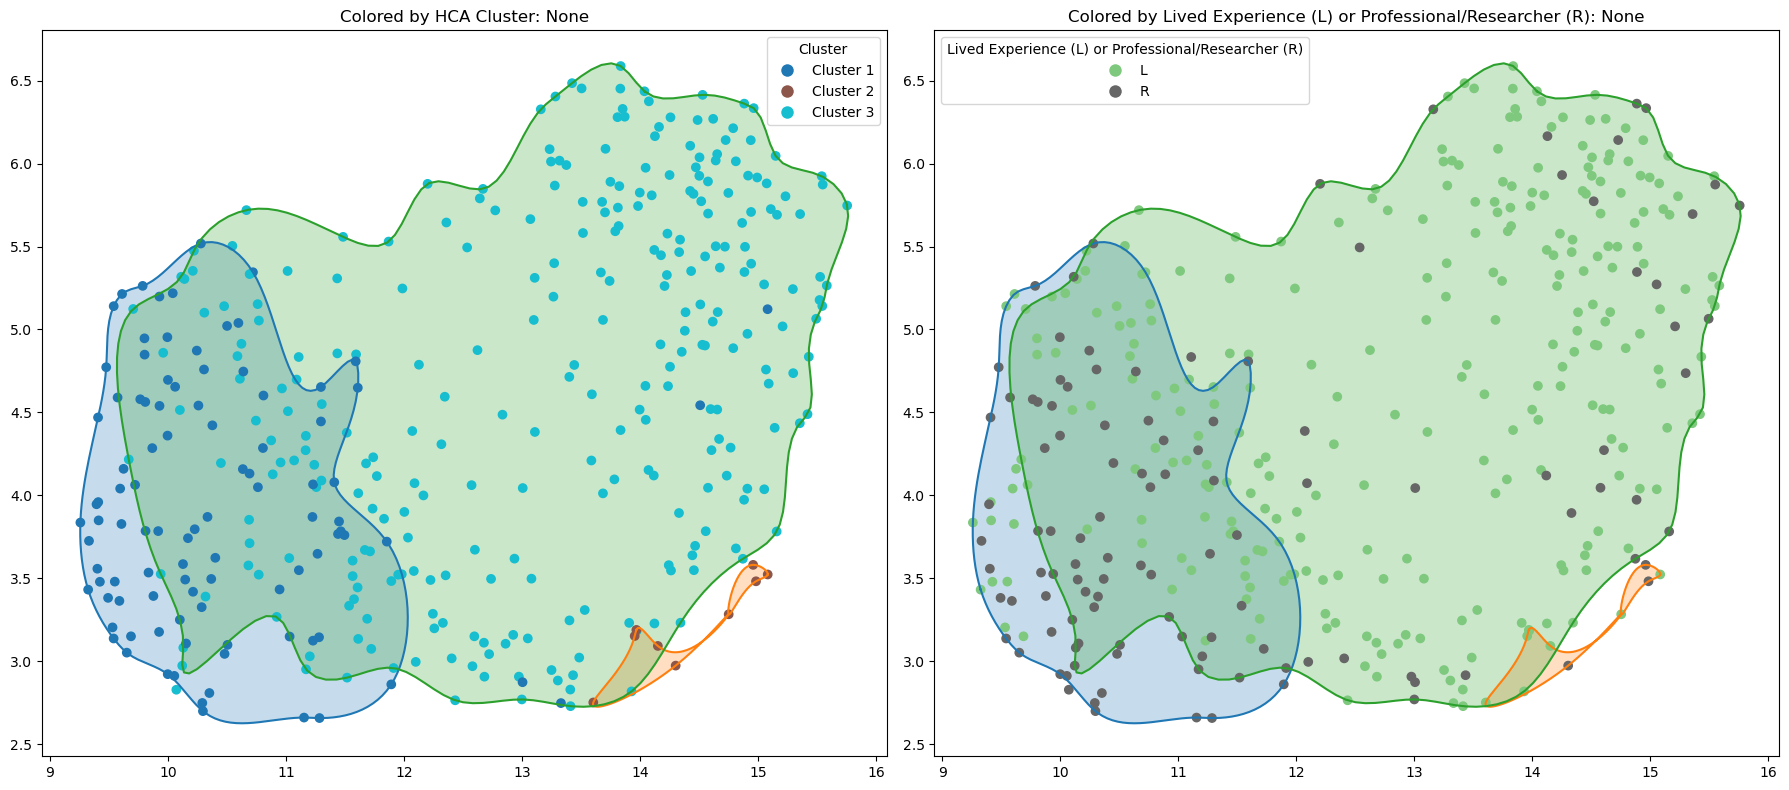

In [ ]:
# assign which clusters to draw hull around
draw_hull_clusters = [1, 2, 3]

# umap clustering
reducer = umap.UMAP(n_components=2
, n_neighbors=15
, min_dist=0.1
, metric='euclidean'
, random_state=42
)
embedding = reducer.fit_transform(X_scaled)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# t value to visualize
clusters = cluster_df['cluster_t3'].values
unique_clusters = np.unique(clusters)

# plot 1: HCA cluster
sc1 = axes[0].scatter(embedding[:, 0], embedding[:, 1], c=clusters, cmap='tab10')
axes[0].set_title(f'Colored by HCA Cluster: {single_column_analysis}')
handles1 = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc1.cmap(sc1.norm(c)), markersize=10) for c in unique_clusters]
axes[0].legend(handles1, [f'Cluster {c}' for c in unique_clusters], title='Cluster')
plot_cluster_hulls(axes[0], embedding, clusters, clusters_to_plot=draw_hull_clusters)

# plot 2: group, with HCA cluster boundaries overlaid
group_codes = df[column].astype('category')
sc2 = axes[1].scatter(embedding[:, 0], embedding[:, 1], c=group_codes.cat.codes, cmap='Accent')
axes[1].set_title(f'Colored by {column}: {single_column_analysis}')
handles2 = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc2.cmap(sc2.norm(i)), markersize=10) for i in range(len(group_codes.cat.categories))]
axes[1].legend(handles2, group_codes.cat.categories, title=column)
plot_cluster_hulls(axes[1], embedding, clusters, clusters_to_plot=draw_hull_clusters)

plt.tight_layout()
plt.show()

### 3D UMAP CLUSTERING

In [27]:
# UMAP with 3 dimensions
reducer_3d = umap.UMAP(n_components=3, random_state=42)
embedding_3d = reducer_3d.fit_transform(X_scaled)

# cluster column to visualize
t = 3
clusters = cluster_df[f'cluster_t{t}'].values

plot_df = pd.DataFrame({
    'UMAP1': embedding_3d[:, 0]
    , 'UMAP2': embedding_3d[:, 1]
    , 'UMAP3': embedding_3d[:, 2]
    , 'Cluster': clusters.astype(str)
    , 'Stakeholder Group': df['Stakeholder Group'].values
    , 'Diagnosis': df['NMOND (N) or MOGAD (M)'].values 
    , 'Country': df['4. Country'].values
    , 'Language': df['Language that survey was completed in'].values
})

fig = px.scatter_3d(plot_df
                    , x='UMAP1'
                    , y='UMAP2'
                    , z='UMAP3'
                    , color='Cluster'
                    , color_discrete_sequence=px.colors.qualitative.Set2
                    , hover_data=['Stakeholder Group', 'Diagnosis', 'Country', 'Language']
                    , title=f'3D UMAP by HCA cluster (t={t})')
fig.update_traces(marker=dict(size=2))
fig.show()

## SUBSET T4 (formerly T3.2) & NMO/MOGAD

In [28]:
# subset T4
t4_cols = [col for col in df_rankings.columns if col.startswith('T4')]
df_rankings_t4 = df_rankings[t4_cols].copy()

# add in missing values 
imputer = SimpleImputer(strategy='median')
X_imputed_t4 = imputer.fit_transform(df_rankings_t4)

# scaling 
scaler = StandardScaler()
X_scaled_t4 = scaler.fit_transform(X_imputed_t4)

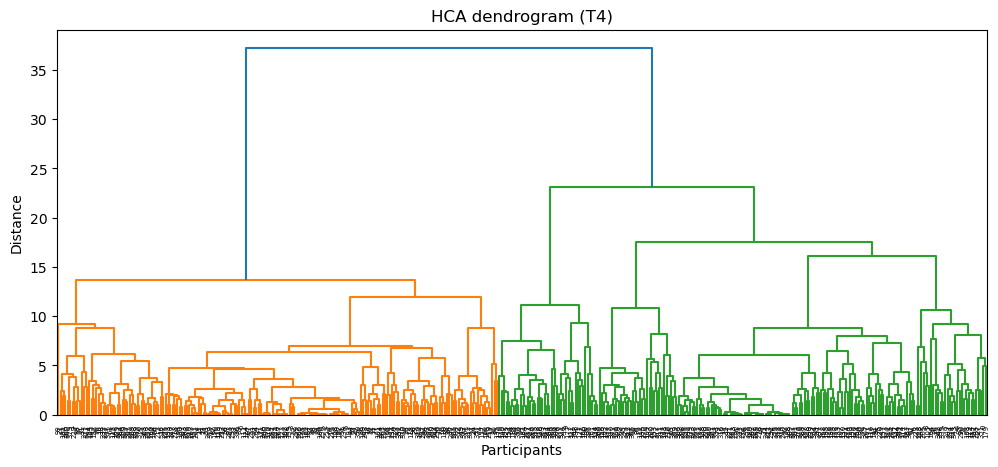

In [29]:
# clustering on subsetted data 
# hierarchical clustering
Z_t4 = sch.linkage(X_scaled_t4, method='ward')

# dendrogram to choose number of clusters
plt.figure(figsize=(12, 5))
sch.dendrogram(Z_t4)
plt.title('HCA dendrogram (T4)')
plt.xlabel('Participants')
plt.ylabel('Distance')
plt.show()


# assign clusters
n_clusters = 3
clusters_t4 = fcluster(Z_t4, t=n_clusters, criterion='maxclust')

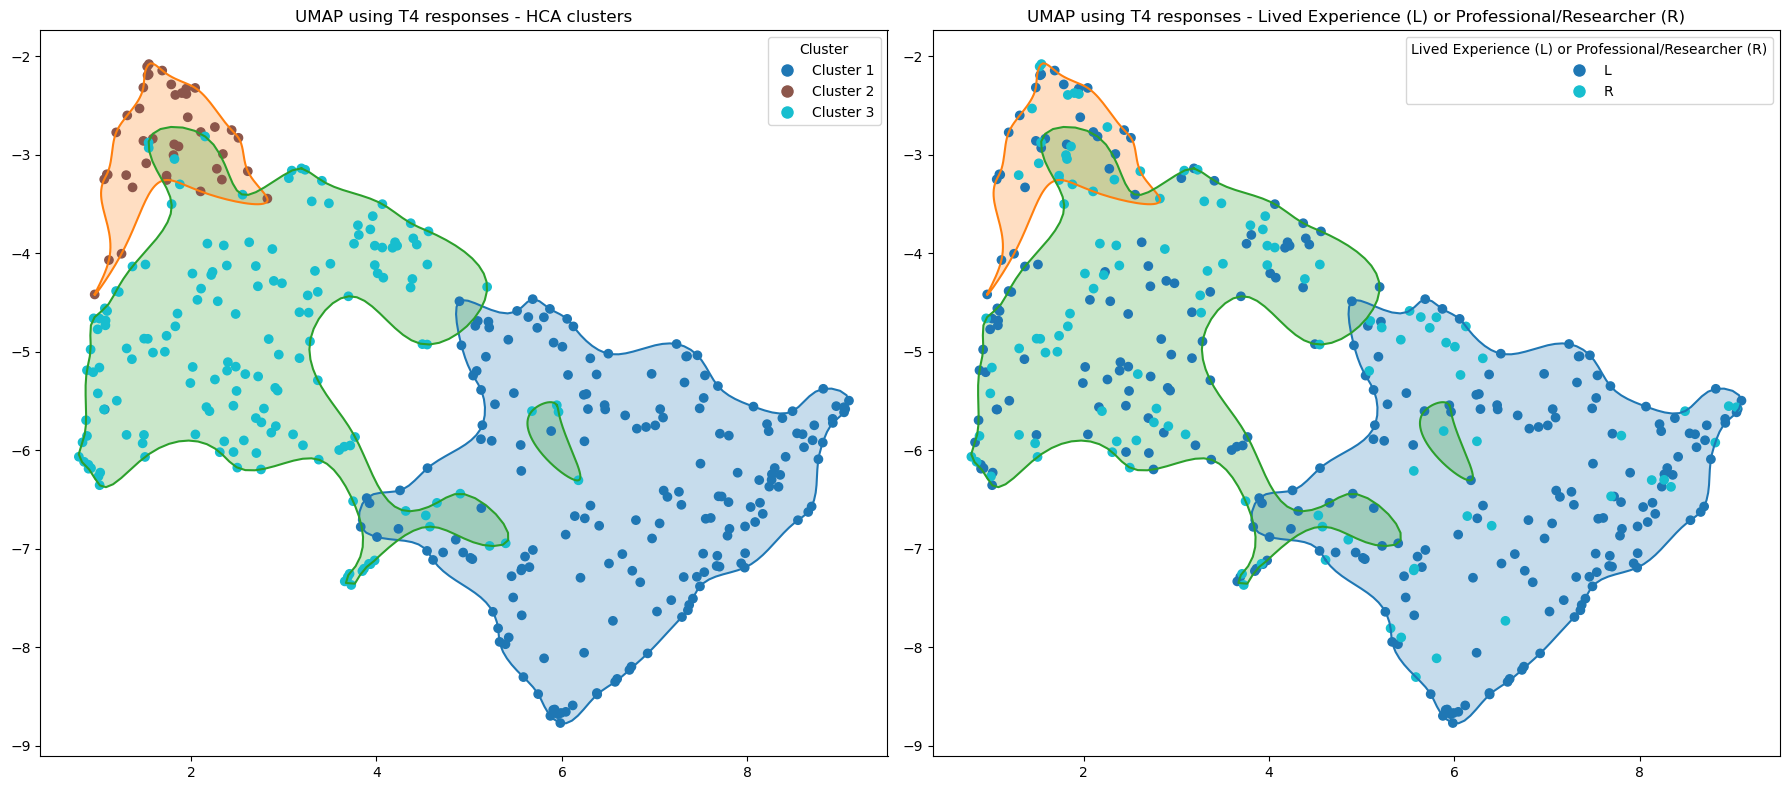

In [ ]:
# assign which clusters to draw hull around
draw_hull_clusters = [1, 2, 3]

# run UMAP 
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

embedding_t4 = reducer.fit_transform(X_scaled_t4)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# HCA cluster labels - same row order as df_rankings_t4
clusters = clusters_t4
group_codes = df[column].astype('category')

# plot 1: HCA cluster
sc1 = axes[0].scatter(embedding_t4[:, 0], embedding_t4[:, 1], c=clusters, cmap='tab10')
axes[0].set_title('UMAP using T4 responses - HCA clusters')
unique_clusters = np.unique(clusters)
handles1 = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc1.cmap(sc1.norm(c)), markersize=10) for c in unique_clusters]
axes[0].legend(handles1, [f'Cluster {c}' for c in unique_clusters], title='Cluster')
plot_cluster_hulls(axes[0], embedding_t4, clusters, clusters_to_plot=draw_hull_clusters)


# plot 2: group, with HCA cluster boundaries overlaid
sc2 = axes[1].scatter(embedding_t4[:, 0], embedding_t4[:, 1], c=group_codes.cat.codes, cmap='tab10')
axes[1].set_title(f'UMAP using T4 responses - {column}')
handles2 = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=sc2.cmap(sc2.norm(i)), markersize=10) for i in range(len(group_codes.cat.categories))]
axes[1].legend(handles2, group_codes.cat.categories, title=column)
plot_cluster_hulls(axes[1], embedding_t4, clusters, clusters_to_plot=draw_hull_clusters)
  

plt.tight_layout()
plt.show()

In [ ]:
# participant lists 
participant_clusters_t4 = pd.DataFrame({
    'Participants': df_rankings_t4.index,
    'cluster_t4': clusters_t4
})

for cluster in sorted(participant_clusters_t4['cluster_t4'].unique()):
    names = (participant_clusters_t4.loc[participant_clusters_t4['cluster_t4'] == cluster, ['Participants']].reset_index(drop=True))
    
    print(f'Cluster {cluster}')
    display(names)
    
    # save each cluster to CSV
    names.to_csv(f'/path/to/file/{cluster}.csv', index=False)

Cluster 1


,Participants
0,Ahactacir Akcbohoba
1,Aida Hauyon-Jaramillo
2,Aisha Be
3,Alyssa Steinmann
4,Amanda Hoebergen
...,...
180,Shuhei Nishiyama
181,T Kann
182,Takeshi Kezuka
183,Tom D'Amato


Cluster 2


,Participants
0,Andra Stroe
1,Danielle Silverman
2,Gabi Pineda Molina
3,Isabella Mora
4,Jodi Arminio
5,Leslie Peng
6,Lois King
7,M642
8,M646
9,M649


Cluster 3


,Participants
0,Adamaris Gonzalez
1,Alanna Yee
2,Amel Kharroubi
3,Amy Martell
4,Angel's iPhone
...,...
158,Tammy Smith
159,Tatsuro Misu
160,Vinícius de Oliveira Boldrini
161,Vinicius Schoeps


In [32]:
top_questions_t4 = {}

for c in sorted(np.unique(clusters_t4)):
    
    # participants belonging to this cluster
    mask = (clusters_t4 == c)
    
    # mean T4 rating within cluster
    cluster_mean = df_rankings_t4.loc[mask].mean()

    # Top 10 highest-rated T4 questions
    result = (
        cluster_mean
        .sort_values(ascending=False)
        .head(10)
        .to_frame(name="cluster_mean")
    )

    top_questions_t4[c] = result

    print(f"\n{'='*60}")
    print(f"Cluster {c} (n={mask.sum()}) — Top 10 highest-rated T4 questions")
    print(f"{'='*60}")
    display(result)


Cluster 1 (n=185) — Top 10 highest-rated T4 questions


,cluster_mean
T4: 70. Mental health,0.576930
T4: 72. Employment and income,0.425578
T4: 65. Lifestyle modifications,0.155308
T4: 69. Daily activities,0.155308
T4: 67. Neuropsychological testing,0.025578
T4: 68. Heat intolerance,0.020173
T4: 71. Relationships,-0.017665
T4: 66. Complementary/alternative therapies,-0.087935



Cluster 2 (n=42) — Top 10 highest-rated T4 questions


,cluster_mean
T4: 72. Employment and income,-1.732204
T4: 65. Lifestyle modifications,-2.184585
T4: 70. Mental health,-2.184585
T4: 68. Heat intolerance,-2.422680
T4: 66. Complementary/alternative therapies,-2.517919
T4: 67. Neuropsychological testing,-2.541728
T4: 69. Daily activities,-2.565538
T4: 71. Relationships,-2.613157



Cluster 3 (n=163) — Top 10 highest-rated T4 questions


,cluster_mean
T4: 67. Neuropsychological testing,-0.301625
T4: 72. Employment and income,-0.448865
T4: 70. Mental health,-0.485675
T4: 65. Lifestyle modifications,-0.724938
T4: 66. Complementary/alternative therapies,-1.148251
T4: 68. Heat intolerance,-1.246411
T4: 69. Daily activities,-1.455000
T4: 71. Relationships,-1.626779


## HIGH RANKERS

In [33]:
high_rank_df = df.copy()


In [ ]:
# get the ranking (T#) columns vs. demographic columns
t_col_pattern = re.compile(r'^T\d+(\.\d+)?:')  # matches T1:, T2:, T3:, T4:, T5:, T6:, T7:

t_cols = [c for c in high_rank_df.columns if t_col_pattern.match(c)]
demo_cols = [c for c in high_rank_df.columns if not t_col_pattern.match(c)]

print(f"Found {len(t_cols)} ranking columns and {len(demo_cols)} demographic columns")

# calculate the % of their ANSWERED questions that were a 9 (for each participant); use answered questions because some people may have skipped
def pct_ranked_9(row):
    answers = row[t_cols].dropna()
    if len(answers) == 0:
        return 0
    return (answers == 9).sum() / len(answers)

high_rank_df['pct_9'] = high_rank_df.apply(pct_ranked_9, axis=1)

# filter participants who ranked >75% of their answers as a 9
high_rankers = high_rank_df[high_rank_df['pct_9'] > 0.75]

print(f"{len(high_rankers)} participants ranked >75% of their answers as a 9")

# pull just the demographic columns (plus the pct_9 column if you want to keep it for reference)
high_rankers_demo = high_rankers[demo_cols + ['pct_9']]

# export to CSV
# high_rankers_demo.to_csv('/path/to/file', index=False)

Found 97 ranking columns and 11 demographic columns
51 participants ranked >75% of their answers as a 9
